#  AI-Powered Web Crawler for Real Estate Market Analysis

##  Project Overview

This project is an end-to-end data-driven system designed to collect, analyze, and predict real estate property prices using machine learning techniques.

The system begins with **web scraping**, where property data is extracted from real estate websites. The collected data includes important features such as property prices, locations, property types, sizes, number of bedrooms, bathrooms, and available amenities.

After data collection, the raw dataset undergoes **data cleaning and preprocessing**, where missing values are handled, and outliers are treated to ensure high-quality data. Feature engineering techniques are applied to transform categorical variables into numerical form and prepare the dataset for model training.

The project applies multiple **supervised machine learning models** such as:
- Linear Regression
- Random Forest
- Decision Tree
- XGBoost / CatBoost (advanced models)

These models are used to predict property prices, and their performance is evaluated using metrics like:
- R² Score
- Mean Square Error (MSE)
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

In addition to prediction, the project focuses on **data analysis and insight generation**, including:
- Location-wise price trends
- Property type comparisons
- Impact of features on price

Finally, all insights, visualizations, and predictions are deployed using an **interactive flask web application**, allowing users to explore the data and predict property prices in real time.

---

##  Objectives

- Automate real estate data collection using web scraping  
- Perform data cleaning and preprocessing  
- Build and compare machine learning models  
- Analyze real estate market trends  
- Develop an interactive price prediction system  

---

##  Technologies Used

- **Programming Language:** Python  
- **Web Scraping:** Scrapy, Selenium
- **Data Analysis:** Pandas, NumPy  
- **Visualization:** Matplotlib, Seaborn  
- **Machine Learning:** Scikit-learn, XGBoost, CatBoost  
- **Deployment:** Streamlit & Flask

---

##  Expected Outcome

- Clean and structured real estate dataset  
- Accurate property price prediction models  
- Insightful visualizations for market analysis  
- Interactive web application for real-time predictions  

---

**INSTALL CATBOOST MODEL**

In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


**IMPORT LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
import joblib

**UPLOAD & READ FILES**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving gujarat_real_estate_properties.csv to gujarat_real_estate_properties.csv


In [4]:
df = pd.read_csv("gujarat_real_estate_properties.csv")
df

,city,location,price,area_sqft,bhk,furnishing,property_age,parking,lift,balcony
0,Ahmedabad,NaN,2821533,489.0,1,NaN,NaN,0,1,0
1,Ahmedabad,Satellite,2900112,499.0,1,Fully Furnished,2.0,0,0,0
2,Ahmedabad,Bopal,3262895,567.0,1,Fully Furnished,1.0,0,1,1
3,Ahmedabad,Satellite,5531610,963.0,2,NaN,NaN,1,0,1
4,Ahmedabad,Vastrapur,6607744,1122.0,3,Semi-Furnished,10.0,1,1,1
...,...,...,...,...,...,...,...,...,...,...
814,Junagadh,Kalva Chowk,2413871,597.0,1,NaN,NaN,1,0,0
815,Junagadh,NaN,7904677,1936.0,3,Semi-Furnished,2.0,1,0,0
816,Junagadh,Madhuram,5019083,1266.0,3,NaN,NaN,0,1,0
817,Junagadh,NaN,2312013,574.0,1,Semi-Furnished,NaN,0,0,0


**BASIC INSPECTION**

In [5]:
print("shape:\n",df.shape)

shape:
 (819, 10)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          819 non-null    object 
 1   location      535 non-null    object 
 2   price         819 non-null    int64  
 3   area_sqft     696 non-null    float64
 4   bhk           819 non-null    int64  
 5   furnishing    478 non-null    object 
 6   property_age  430 non-null    float64
 7   parking       819 non-null    int64  
 8   lift          819 non-null    int64  
 9   balcony       819 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 64.1+ KB


In [7]:
df.describe()

,price,area_sqft,bhk,property_age,parking,lift,balcony
count,8.190000e+02,696.000000,819.000000,430.000000,819.000000,819.000000,819.000000
mean,4.644845e+06,946.353448,1.893773,4.546512,0.506716,0.483516,0.500611
std,1.913422e+06,383.438174,0.780068,3.584664,0.500260,0.500034,0.500305
min,1.860130e+06,450.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,3.020163e+06,630.750000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,4.236850e+06,874.500000,2.000000,2.000000,1.000000,0.000000,1.000000
75%,6.092870e+06,1170.000000,3.000000,10.000000,1.000000,1.000000,1.000000
max,1.049271e+07,1985.000000,3.000000,10.000000,1.000000,1.000000,1.000000


In [8]:
print("columns:\n", df.columns)

columns:
 Index(['city', 'location', 'price', 'area_sqft', 'bhk', 'furnishing',
       'property_age', 'parking', 'lift', 'balcony'],
      dtype='object')


**CHECKING NULL VALUES**

In [9]:
df.isnull().sum()

,0
city,0
location,284
price,0
area_sqft,123
bhk,0
furnishing,341
property_age,389
parking,0
lift,0
balcony,0


In [10]:
df.isnull().sum().sum()

np.int64(1137)

**FILLING MISSING VALUES USING bfill & ffill METHOD**


**ffill (forward fill):** Fills missing values using the previous (above) value.

**bfill (backward fill):** Fills missing values using the next (below) value.


In [11]:
df = df.ffill().bfill()

In [12]:
df.isnull().sum()

,0
city,0
location,0
price,0
area_sqft,0
bhk,0
furnishing,0
property_age,0
parking,0
lift,0
balcony,0


In [13]:
df.isnull().sum().sum()

np.int64(0)

**CHECKING OUTLIERS**

An **outlier** is a data point that is significantly different from the rest of the dataset.


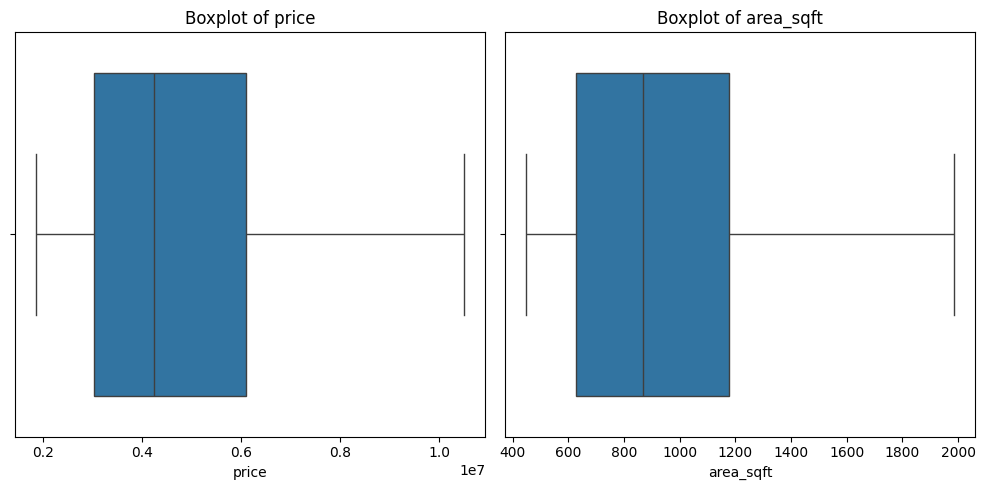

In [14]:
num_cols = ['price','area_sqft']
plt.figure(figsize=(10,5))
for i,col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

**EDA**

**EDA (Exploratory Data Analysis):** The process of analyzing and summarizing a dataset to understand its patterns, relationships, and key features.


***1)Univariate Analysis (numerical)***

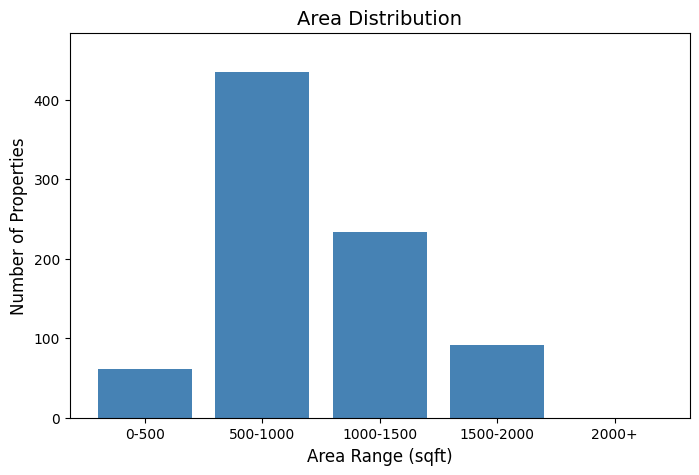

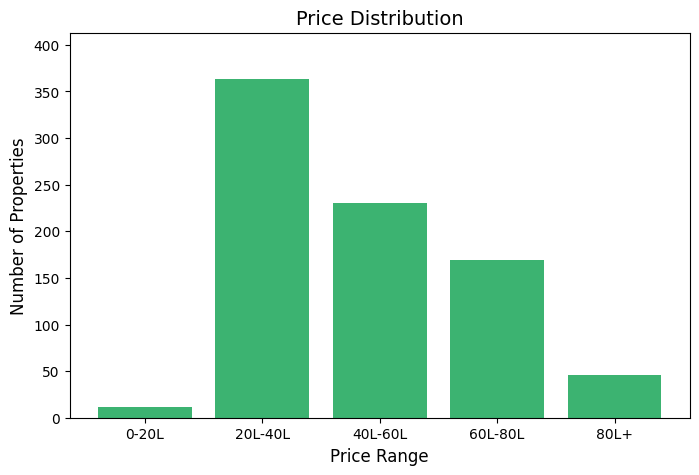

In [15]:
area_bins = [0, 500, 1000, 1500, 2000, 100000]
area_labels = ["0-500", "500-1000", "1000-1500", "1500-2000", "2000+"]
df["area_range"] = pd.cut(
    df["area_sqft"],
    bins=area_bins,
    labels=area_labels,
    include_lowest=True
)
area_counts = df["area_range"].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(area_counts.index, area_counts.values, color="steelblue")
plt.xlabel("Area Range (sqft)", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)
plt.title("Area Distribution", fontsize=14)
plt.xticks(rotation=0)
plt.ylim(0, max(area_counts.values) + 50)
plt.show()

price_bins = [0, 2000000, 4000000, 6000000, 8000000, 100000000]
price_labels = ["0-20L", "20L-40L", "40L-60L", "60L-80L", "80L+"]

df["price_range"] = pd.cut(
    df["price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

price_counts = df["price_range"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(price_counts.index, price_counts.values, color="mediumseagreen")
plt.xlabel("Price Range", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)
plt.title("Price Distribution", fontsize=14)
plt.xticks(rotation=0)
plt.ylim(0, max(price_counts.values) + 50)
plt.show()


In [16]:
df.drop(["area_range", "price_range"], axis=1, inplace=True)

In [17]:
df.columns

Index(['city', 'location', 'price', 'area_sqft', 'bhk', 'furnishing',
       'property_age', 'parking', 'lift', 'balcony'],
      dtype='object')

***2) Univariate Analysis (categorical)***

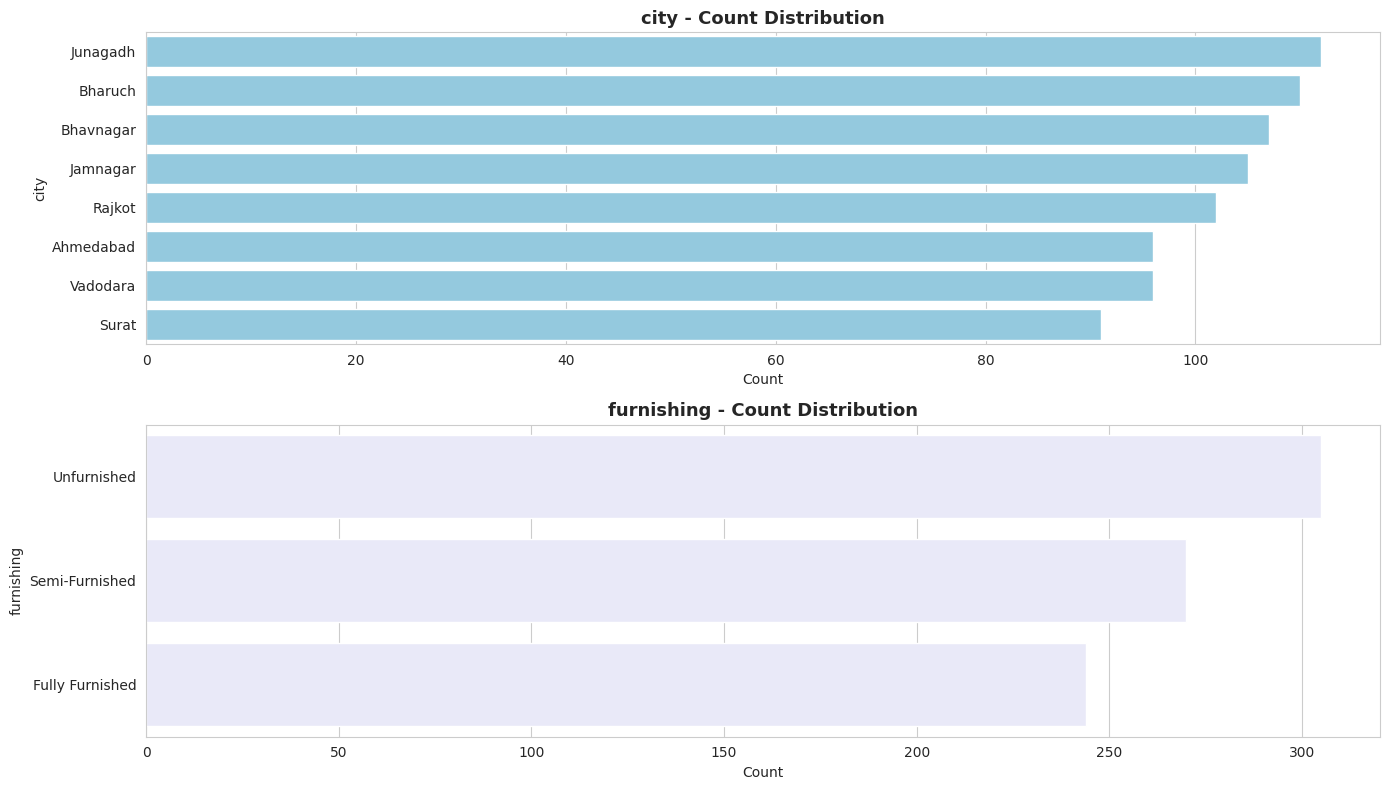

In [18]:
sns.set_style("whitegrid")
eda_cat_cols = ["city",  "furnishing"]
colors = ["skyblue",  "lavender"]
plt.figure(figsize=(14, len(eda_cat_cols)*4))
for i, col in enumerate(eda_cat_cols):
    plt.subplot(len(eda_cat_cols), 1, i+1)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index,
        color=colors[i]
    )
    plt.title(f"{col} - Count Distribution", fontsize=13, fontweight='bold')
    plt.xlabel("Count")
    plt.ylabel(col)
plt.tight_layout()
plt.show()


***3.1)Bivariate Analysis (numerical vs numerical)***

price vs area_sqft

/tmp/ipykernel_294/555218401.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_group = df.groupby('area_bins')['price_lakh'].mean().reset_index()
/tmp/ipykernel_294/555218401.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


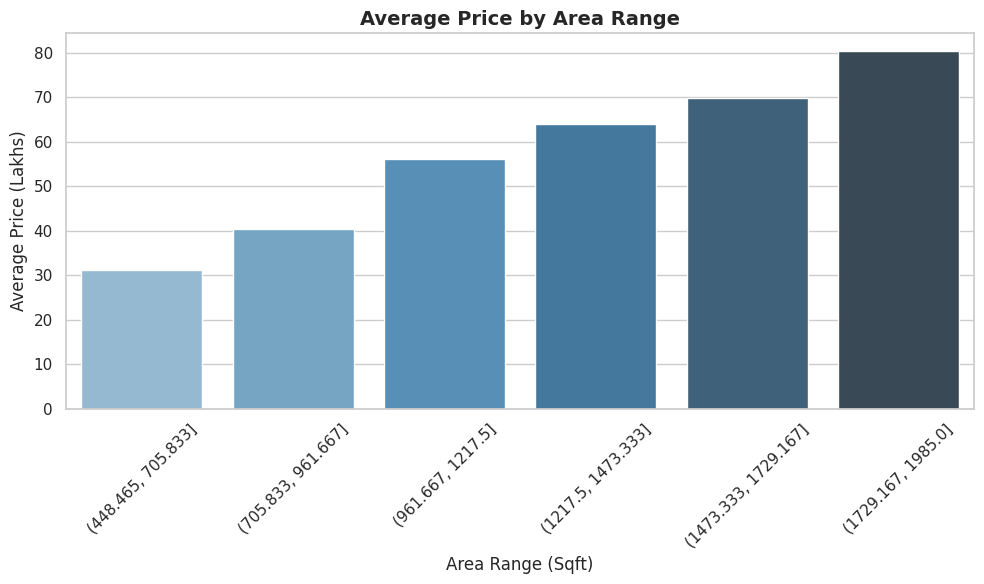

In [19]:
sns.set(style="whitegrid")
df['price_lakh'] = df['price'] / 100000

# Area bins
df['area_bins'] = pd.cut(df['area_sqft'], bins=6)

# Grouping
area_group = df.groupby('area_bins')['price_lakh'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    x='area_bins',
    y='price_lakh',
    data=area_group,
    palette="Blues_d"
)

plt.title("Average Price by Area Range", fontsize=14, fontweight="bold")
plt.xlabel("Area Range (Sqft)")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [20]:
df.drop(["area_bins", "price_lakh"], axis=1, inplace=True)

In [21]:
df.columns

Index(['city', 'location', 'price', 'area_sqft', 'bhk', 'furnishing',
       'property_age', 'parking', 'lift', 'balcony'],
      dtype='object')

***3.2)Bivariate Analysis (numerical vs categorical)***

price vs city

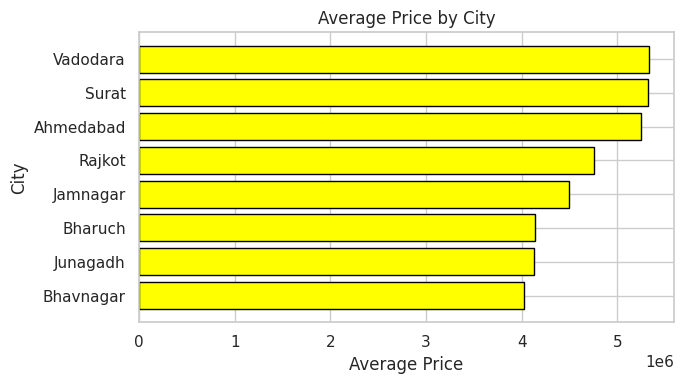

In [22]:
avg_price_city = df.groupby('city')['price'].mean().sort_values()
plt.figure(figsize=(7,4))
plt.barh(avg_price_city.index, avg_price_city.values, edgecolor='black', color='yellow')
plt.title('Average Price by City')
plt.xlabel('Average Price')
plt.ylabel('City')
plt.tight_layout()
plt.show()

***3.3)Bivariate Analysis (categorical vs categorical)***

city vs furnishing

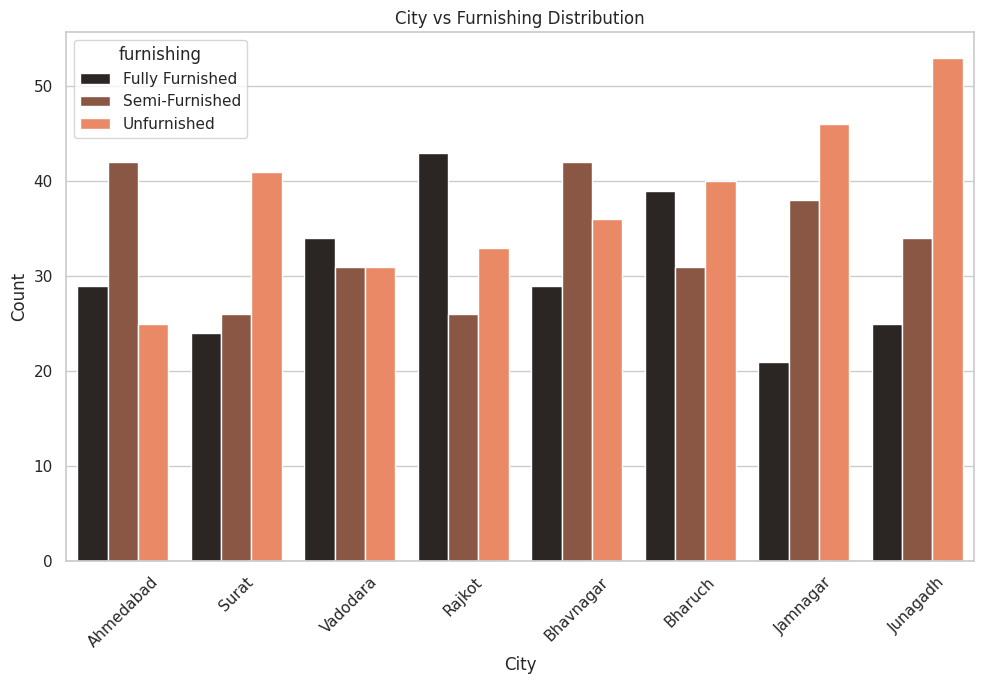

In [23]:
plt.figure(figsize=(10,7))
sns.countplot(
    data=df,
    x='city',
    hue='furnishing',
    palette='dark:coral'
)
plt.title('City vs Furnishing Distribution')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

***4)Multivariate Analysis***

/tmp/ipykernel_294/1599876561.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(y)}L" for y in ax.get_yticks()])


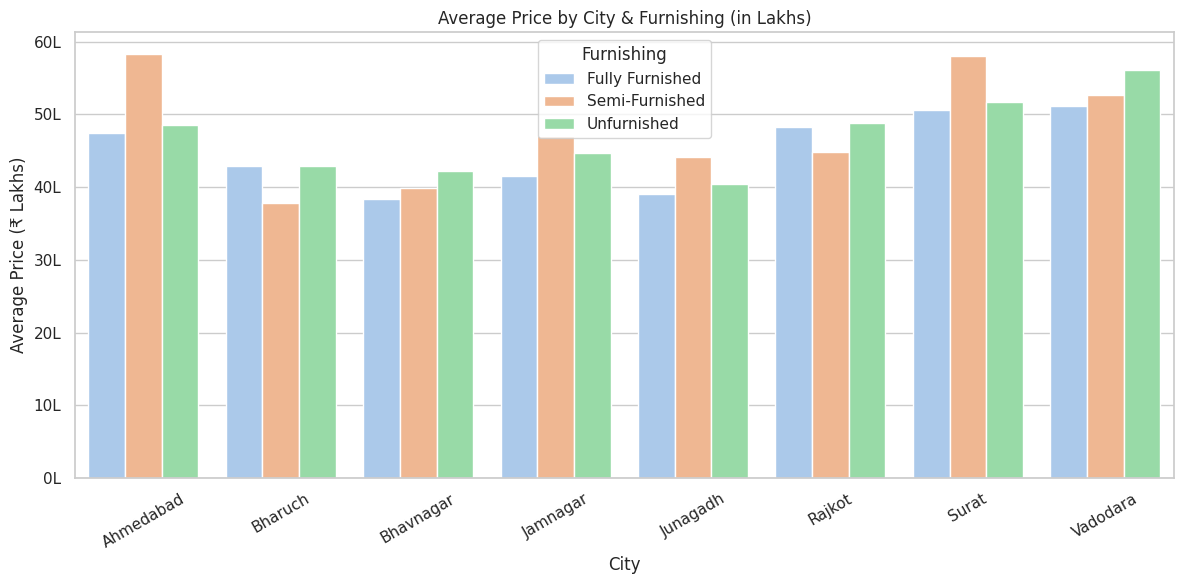

In [24]:
grp = df.groupby(['city', 'furnishing'])['price'].mean().reset_index()
grp['price_lakh'] = grp['price'] / 100000
sns.set(style="whitegrid")

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x='city',
    y='price_lakh',
    hue='furnishing',
    data=grp,
    palette='pastel'
)

plt.title("Average Price by City & Furnishing (in Lakhs)")
plt.xlabel("City")
plt.ylabel("Average Price (₹ Lakhs)")
plt.xticks(rotation=30)

ax.set_yticklabels([f"{int(y)}L" for y in ax.get_yticks()])

plt.legend(title="Furnishing")
plt.tight_layout()
plt.show()

In [25]:
df.columns

Index(['city', 'location', 'price', 'area_sqft', 'bhk', 'furnishing',
       'property_age', 'parking', 'lift', 'balcony'],
      dtype='object')

**CATBOOST MODEL**

**CatBoost:**

CatBoost is a gradient boosting algorithm that efficiently handles categorical features using ordered boosting, providing high accuracy with minimal preprocessing.



In [26]:
X = df.drop('price', axis=1)
y = df['price']

In [27]:
cat_features = ['city','location','furnishing']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 1834676.6356687	total: 48ms	remaining: 24s
100:	learn: 447202.2949103	total: 241ms	remaining: 952ms
200:	learn: 315153.5211469	total: 448ms	remaining: 667ms
300:	learn: 253656.6023416	total: 655ms	remaining: 433ms
400:	learn: 218392.9585318	total: 871ms	remaining: 215ms
499:	learn: 192687.9485650	total: 1.09s	remaining: 0us


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [30]:
y_pred = model.predict(X_test)

In [31]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("CATBOOST RESULT:")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

CATBOOST RESULT:
R2 Score: 0.9622096623382039
MAE: 243583.12339262836
MSE: 144138685508.4182
RMSE: 379656.00944594335


**ENCODING**

**Encoding:** The process of converting categorical (text) data into numerical form so that machine learning models can understand and use it.


In [32]:
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_cols)

Categorical Columns: Index(['city', 'location', 'furnishing'], dtype='object')


In [33]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

In [34]:
print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (819, 10)
Encoded Shape: (819, 47)


In [35]:
print(df_encoded.columns)

Index(['price', 'area_sqft', 'bhk', 'property_age', 'parking', 'lift',
       'balcony', 'city_Ahmedabad', 'city_Bharuch', 'city_Bhavnagar',
       'city_Jamnagar', 'city_Junagadh', 'city_Rajkot', 'city_Surat',
       'city_Vadodara', 'location_150 Feet Ring Rd', 'location_Adajan',
       'location_Alkapuri', 'location_Ankleshwar', 'location_Bopal',
       'location_Gota', 'location_Gotri', 'location_Gulab Nagar',
       'location_Indira Marg', 'location_Joshipura', 'location_Kalawad Road',
       'location_Kalva Chowk', 'location_Karelibaug', 'location_Katargam',
       'location_Link Road', 'location_Madhuram', 'location_Maninagar',
       'location_Manjalpur', 'location_Nilambag', 'location_Patel Colony',
       'location_Piplod', 'location_Sardar Nagar', 'location_Satellite',
       'location_Talaja Road', 'location_University Road', 'location_Varachha',
       'location_Vastrapur', 'location_Vesu', 'location_Zadeshwar',
       'furnishing_Fully Furnished', 'furnishing_Semi-Furnish

In [36]:
print(df_encoded.dtypes)

price                           int64
area_sqft                     float64
bhk                             int64
property_age                  float64
parking                         int64
lift                            int64
balcony                         int64
city_Ahmedabad                   bool
city_Bharuch                     bool
city_Bhavnagar                   bool
city_Jamnagar                    bool
city_Junagadh                    bool
city_Rajkot                      bool
city_Surat                       bool
city_Vadodara                    bool
location_150 Feet Ring Rd        bool
location_Adajan                  bool
location_Alkapuri                bool
location_Ankleshwar              bool
location_Bopal                   bool
location_Gota                    bool
location_Gotri                   bool
location_Gulab Nagar             bool
location_Indira Marg             bool
location_Joshipura               bool
location_Kalawad Road            bool
location_Kal

In [37]:
df_encoded = df_encoded.astype(int)

In [38]:
print(df_encoded.dtypes)

price                         int64
area_sqft                     int64
bhk                           int64
property_age                  int64
parking                       int64
lift                          int64
balcony                       int64
city_Ahmedabad                int64
city_Bharuch                  int64
city_Bhavnagar                int64
city_Jamnagar                 int64
city_Junagadh                 int64
city_Rajkot                   int64
city_Surat                    int64
city_Vadodara                 int64
location_150 Feet Ring Rd     int64
location_Adajan               int64
location_Alkapuri             int64
location_Ankleshwar           int64
location_Bopal                int64
location_Gota                 int64
location_Gotri                int64
location_Gulab Nagar          int64
location_Indira Marg          int64
location_Joshipura            int64
location_Kalawad Road         int64
location_Kalva Chowk          int64
location_Karelibaug         

**DOWNLOAD CLEAN DATASET**

In [39]:
df_encoded.to_csv("cleaned_dataset.csv", index=False)
print("Clean dataset saved as cleaned_dataset.csv")

Clean dataset saved as cleaned_dataset.csv


In [40]:
from google.colab import files
files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**DECISION TREE**

**Decision Tree:** A machine learning algorithm that makes decisions by splitting data into branches based on conditions, forming a tree-like structure to predict outcomes.


In [41]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [44]:
y_pred = dt_model.predict(X_test)

In [45]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("DECISION TREE RESULT:")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

DECISION TREE RESULT:
R2 Score: 0.9024844395965419
MAE: 378521.2596594208
MSE: 371940701323.2598
RMSE: 609869.4133363796


**RANDOM FOREST**

**Random Forest:** A machine learning algorithm that builds multiple decision trees and combines their outputs to improve accuracy and reduce overfitting.


In [46]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

In [47]:
y_pred_rf = rf_model.predict(X_test)

In [48]:
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)

print("RANDOM FOREST RESULT:")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

RANDOM FOREST RESULT:
R2 Score: 0.9508582206717902
MAE: 251304.58014692744
MSE: 187434987728.98456
RMSE: 432937.62567947886


**XG BOOST**

**XGBoost:** An optimized gradient boosting algorithm that builds decision trees sequentially to improve prediction accuracy and performance.


In [49]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [50]:
y_pred_xgb = xgb_model.predict(X_test)

In [51]:
r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)

print("XGBOOST RESULT:")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

XGBOOST RESULT:
R2 Score: 0.9573242664337158
MAE: 222882.046875
MSE: 162772369408.0
RMSE: 403450.57864377886


**LINEAR REGRESSION**

**Linear Regression:** A statistical and machine learning method that models the relationship between variables by fitting a straight line to predict a continuous outcome.


In [52]:
lr_model = LinearRegression()

In [53]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [54]:
y_pred_lr = lr_model.predict(X_test)

In [55]:
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)

print("LINEAR REGRESSION RESULT:")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

LINEAR REGRESSION RESULT:
R2 Score: 0.8777213915698998
MAE: 516897.0322501435
MSE: 466391119408.57886
RMSE: 682928.3413423247


**Actual vs Predicted**

In [56]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(results.head(10))

   Actual Price  Predicted Price
0       4418636     5.805646e+06
1       4870999     5.057051e+06
2       7077379     6.642803e+06
3       2992047     2.754627e+06
4       2509289     2.397423e+06
5       3951816     3.917534e+06
6       3910787     3.917534e+06
7       6730517     4.706290e+06
8       3064891     2.962940e+06
9       3779913     3.917534e+06


In [57]:
results["Predicted Price"] = results["Predicted Price"].astype(int)

results.head(10)

,Actual Price,Predicted Price
0,4418636,5805646
1,4870999,5057050
2,7077379,6642803
3,2992047,2754626
4,2509289,2397422
5,3951816,3917534
6,3910787,3917534
7,6730517,4706290
8,3064891,2962940
9,3779913,3917534


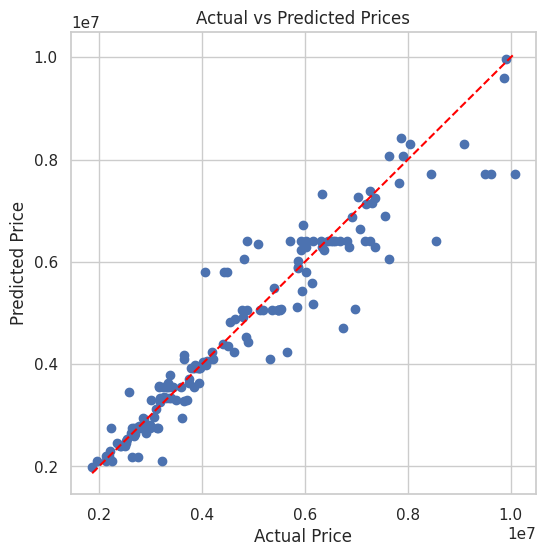

In [58]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='red')

plt.show()

**5 Model Comparison Graph**

In [59]:
r2_catboost = 0.9622096623382039
r2_decision_tree = 0.9024844395965419
r2_random_forest = 0.9508582206717902
r2_xgboost = 0.9573242664337158
r2_linear_regression = 0.8777213915698998

mae_catboost = 243583.12339262836
mae_decision_tree = 378521.2596594208
mae_random_forest = 251304.58014692744
mae_xgboost = 222882.046875
mae_linear_regression = 516897.0322501435

mse_catboost = 144138685508.4182
mse_decision_tree = 371940701323.2598
mse_random_forest = 187434987728.98456
mse_xgboost = 162772369408.0
mse_linear_regression = 466391119408.57886

results_df = pd.DataFrame({
    "Model": ["CatBoost", "Decision Tree", "Random Forest", "XGBoost", "Linear Regression"],
    "R2": [r2_catboost, r2_decision_tree, r2_random_forest, r2_xgboost, r2_linear_regression],
    "MAE": [mae_catboost, mae_decision_tree, mae_random_forest, mae_xgboost, mae_linear_regression],
    "MSE": [mse_catboost, mse_decision_tree, mse_random_forest, mse_xgboost, mse_linear_regression]
})



***R2 Graph Comparison***

In [60]:
fig = px.bar(
    results_df,
    x="Model",
    y="R2",
    color="Model",
    title="Model Comparison - R2 Score",
    text_auto=True
)

fig.show()

***MAE Graph Comparison***

In [61]:
fig = px.bar(
    results_df,
    x="Model",
    y="MAE",
    color="Model",
    title="Model Comparison - MAE",
    text_auto=True
)

fig.show()

***MSE Graph Comparison***

In [62]:
fig = px.bar(
    results_df,
    x="Model",
    y="MSE",
    color="Model",
    title="Model Comparison - MSE",
    text_auto=True
)

fig.show()

**SAVE BEST MODEL**

In [63]:
joblib.dump(model, "catboost_model(final).joblib")
print("MODEL SAVED SUCCESSFULLY")

MODEL SAVED SUCCESSFULLY
